In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [2]:
forward_ratings = pd.read_csv('data/forward_ratings.csv')
midfielder_ratings = pd.read_csv('data/midfielder_ratings.csv')
tagged_mf_ratings = pd.read_csv('data/tagged_midfielder_ratings.csv')
defender_ratings = pd.read_csv('data/defender_ratings.csv')
goalkeeper_ratings = pd.read_csv('data/goalkeeper_ratings.csv')

print(forward_ratings.shape, midfielder_ratings.shape, tagged_mf_ratings.shape,
      defender_ratings.shape, goalkeeper_ratings.shape)

(195, 98) (463, 100) (185, 103) (502, 101) (121, 36)


In [3]:
def top_n(df, subtype_col, subtype_value, n):
    return df[df[subtype_col] == subtype_value].sort_values('rating', ascending=False).head(n)

best_gk = goalkeeper_ratings.sort_values('rating', ascending=False).head(1)
best_cb = top_n(defender_ratings, 'defender_subtype', 'Centre-Back', 2)
best_wb = top_n(defender_ratings, 'defender_subtype', 'Wingback', 2)
best_holding = top_n(midfielder_ratings, 'midfielder_subtype', 'Holding Midfielder', 1)
best_am = top_n(tagged_mf_ratings, 'midfielder_subtype', 'Attacking Midfielder (MF,FW)', 2)
best_central_fw = top_n(forward_ratings, 'forward_subtype', 'Central Forward', 1)
best_wide_fw = top_n(forward_ratings, 'forward_subtype', 'Wide Forward', 2)

best_xi = pd.concat([
    best_gk[['Player', 'Squad', 'league', 'rating']].assign(role='GK'),
    best_cb[['Player', 'Squad', 'league', 'rating']].assign(role='CB'),
    best_wb[['Player', 'Squad', 'league', 'rating']].assign(role='WB'),
    best_holding[['Player', 'Squad', 'league', 'rating']].assign(role='Holding MF'),
    best_am[['Player', 'Squad', 'league', 'rating']].assign(role='Attacking MF'),
    best_central_fw[['Player', 'Squad', 'league', 'rating']].assign(role='Central FW'),
    best_wide_fw[['Player', 'Squad', 'league', 'rating']].assign(role='Wide FW'),
], ignore_index=True)

print(best_xi.to_string(index=False))

            Player        Squad         league  rating         role
 Lorenzo Palmisani    Frosinone        Serie B    75.3           GK
    Adrien Monfray       Troyes        Ligue 2    69.8           CB
      Harold Voyer      Le Mans        Ligue 2    66.4           CB
 Maximilian Wittek       Bochum  2. Bundesliga    66.7           WB
    Tim Handwerker      Arminia  2. Bundesliga    66.0           WB
      Enzo Leopold  Hannover 96  2. Bundesliga    71.1   Holding MF
       Léo Scienza  Southampton   Championship    64.2 Attacking MF
Chrystian Barletta Sport Recife Brazil Serie B    63.6 Attacking MF
            Mikael          CRB Brazil Serie B    67.6   Central FW
        Barış Atik    Magdeburg  2. Bundesliga    62.2      Wide FW
     Fabio Maistro  Juve Stabia        Serie B    61.0      Wide FW


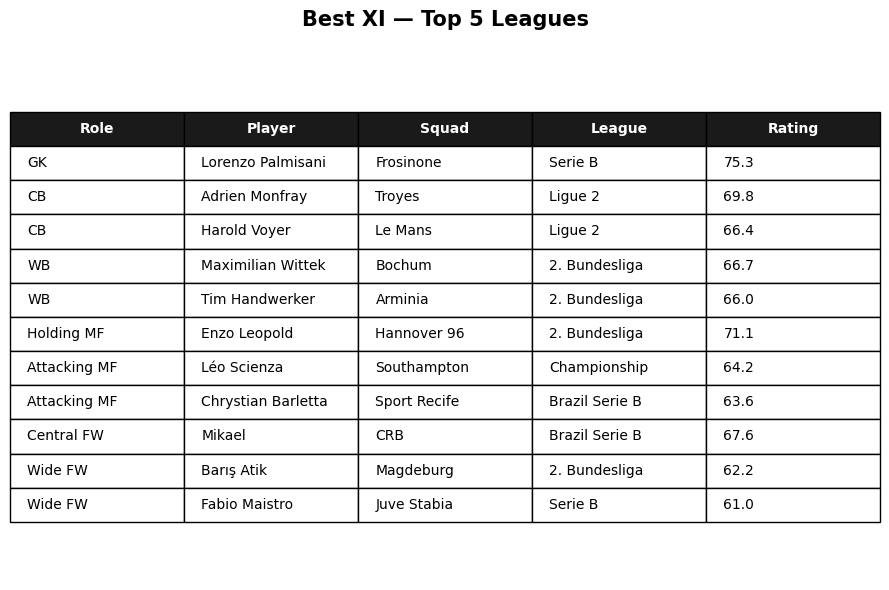

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.axis('off')

table_data = best_xi[['role', 'Player', 'Squad', 'league', 'rating']].values
col_labels = ['Role', 'Player', 'Squad', 'League', 'Rating']

table = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

for i in range(len(col_labels)):
    table[(0, i)].set_facecolor('#1a1a1a')
    table[(0, i)].set_text_props(color='white', fontweight='bold')

plt.title('Best XI — Top 5 Leagues', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('best_xi_table.png', dpi=200, bbox_inches='tight')
plt.show()

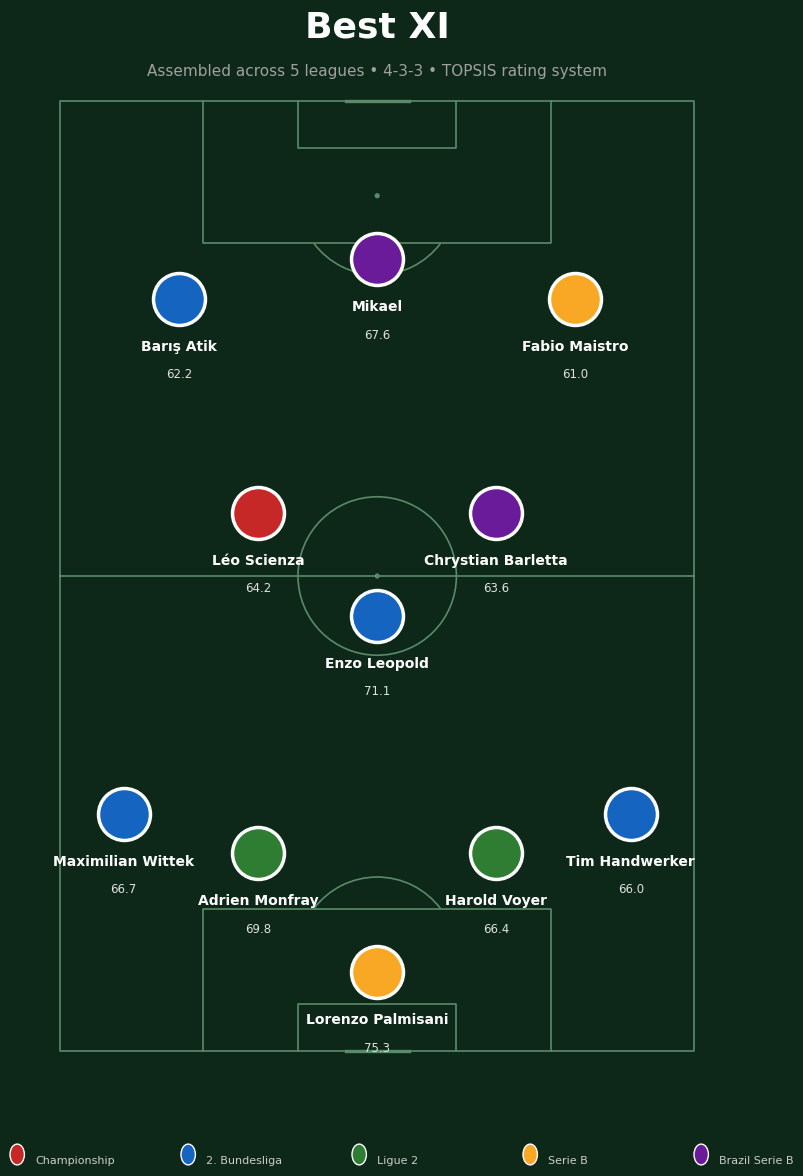

In [12]:
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt

positions = {
    'GK': [(10, 40)],
    'CB': [(25, 25), (25, 55)],
    'WB': [(30, 8), (30, 72)],
    'Holding MF': [(55, 40)],
    'Attacking MF': [(68, 25), (68, 55)],
    'Central FW': [(100, 40)],
    'Wide FW': [(95, 15), (95, 65)],
}

league_colors = {
    'Championship': '#c62828',
    '2. Bundesliga': '#1565c0',
    'Ligue 2': '#2e7d32',
    'Serie B': '#f9a825',
    'Brazil Serie B': '#6a1b9a',
}

fig = plt.figure(figsize=(9, 13), facecolor='#0d2818')

# manually reserve space: top 12% for title, bottom 8% for legend,
# pitch gets the middle - prevents any overlap between the three
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#0d2818', line_color='#5a8a6a', linewidth=1.2)
ax = fig.add_axes([0.05, 0.10, 0.9, 0.78])
pitch.draw(ax=ax)

for role, coords in positions.items():
    players_in_role = best_xi[best_xi['role'] == role].reset_index(drop=True)
    for i, (x, y) in enumerate(coords):
        if i < len(players_in_role):
            player = players_in_role.iloc[i]
            color = league_colors.get(player['league'], '#c62828')

            pitch.scatter(x, y, ax=ax, s=1400, color=color, edgecolors='white', linewidth=2.5, zorder=3)
            pitch.annotate(player['Player'], xy=(x - 6.5, y), ax=ax, ha='center',
                            fontsize=10, fontweight='bold', color='white', zorder=4)
            pitch.annotate(f"{player['rating']:.1f}", xy=(x - 10, y), ax=ax, ha='center',
                            fontsize=8.5, color='#e0e0e0', zorder=4)

# title block - sits ABOVE the pitch's reserved area now
fig.text(0.5, 0.905, "Best XI", fontsize=26, fontweight='bold', ha='center', color='white')
fig.text(0.5, 0.875, "Assembled across 5 leagues \u2022 4-3-3 \u2022 TOPSIS rating system",
          fontsize=11, ha='center', color='#a0a0a0')

# legend - sits BELOW the pitch's reserved area now
legend_y = 0.045
for i, (league, color) in enumerate(league_colors.items()):
    x_pos = 0.10 + i * 0.19
    fig.patches.append(plt.Circle((x_pos, legend_y), 0.008, transform=fig.transFigure,
                                     color=color, ec='white', linewidth=1))
    fig.text(x_pos + 0.02, legend_y - 0.005, league, fontsize=8, color='#cccccc', va='center')

plt.savefig('best_xi_pitch.png', dpi=200, facecolor='#0d2818', bbox_inches='tight')
plt.show()

